# KNN Regression

В этом ноутбуке посмотрим:
- как работает KNN на примере
- зачем нужно масштабирование признаков
- как влияет количество соседей
- разницу между весами
- метрики качества: MSE, RMSE, MAE, R²

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Генерируем данные

Создадим синтетический набор: `y = sin(x) + шум`.

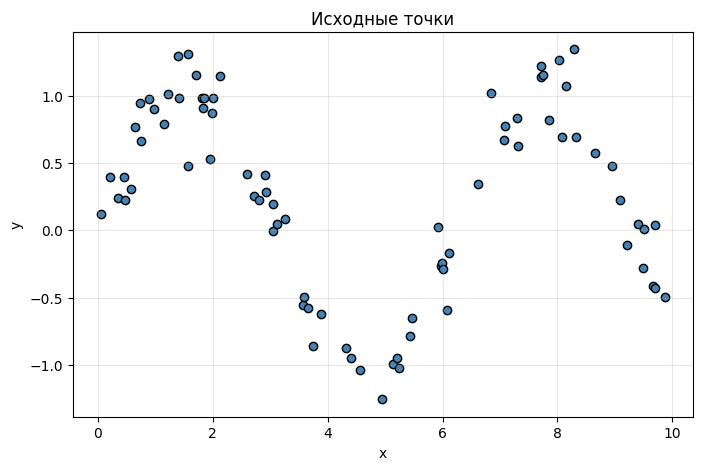

In [2]:
X = np.sort(np.random.uniform(0, 10, 80)).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, X.shape[0])

plt.scatter(X, y, color='steelblue', edgecolor='k')
plt.title('Исходные точки')
plt.xlabel('x'); plt.ylabel('y')
plt.grid(alpha=0.3)
plt.show()

## 2. Как KNN предсказывает по ближайшим соседям

Возьмём `k=5` и обучим модель.

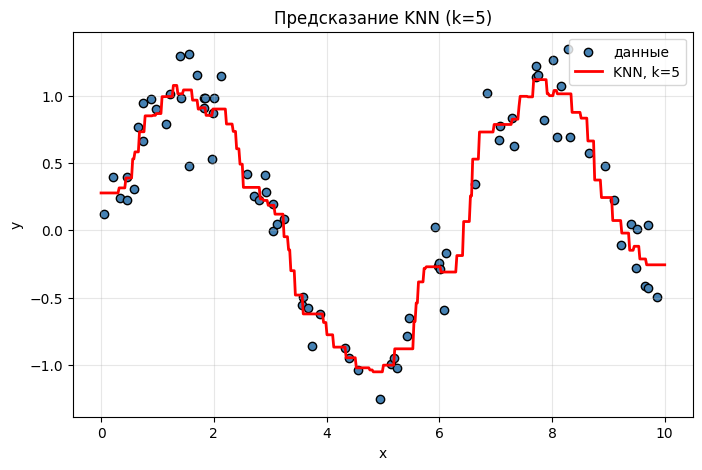

In [3]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X, y)

X_grid = np.linspace(0, 10, 500).reshape(-1, 1)
y_pred = knn.predict(X_grid)

plt.scatter(X, y, color='steelblue', edgecolor='k', label='данные')
plt.plot(X_grid, y_pred, color='red', lw=2, label='KNN, k=5')
plt.title('Предсказание KNN (k=5)')
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 3. Почему важно масштабирование признаков

KNN считает расстояния. Если один признак измеряется в тысячах, а другой — в десятых, то «большой» признак полностью задавит «маленький». Сделаем 2 признака с разными масштабами и сравним.

In [4]:
n = 200
x1 = np.random.uniform(0, 1, n)
x2 = np.random.uniform(0, 1000, n)
y2 = 5*x1 + 0.01*x2 + np.random.normal(0, 0.1, n)

X2 = np.column_stack([x1, x2])
X_tr, X_te, y_tr, y_te = train_test_split(X2, y2, test_size=0.3, random_state=42)

# Без масштабирования
knn_raw = KNeighborsRegressor(n_neighbors=5).fit(X_tr, y_tr)
r2_raw = r2_score(y_te, knn_raw.predict(X_te))

# С масштабированием
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)
knn_scaled = KNeighborsRegressor(n_neighbors=5).fit(X_tr_s, y_tr)
r2_scaled = r2_score(y_te, knn_scaled.predict(X_te_s))

print(f'R² без масштабирования: {r2_raw:.3f}')
print(f'R² с масштабированием: {r2_scaled:.3f}')

R² без масштабирования: 0.731
R² с масштабированием: 0.989


Видно: после `StandardScaler` модель работает заметно лучше.

## 4. Влияние количества соседей

Маленькое `k` → переобучение (модель прыгает за каждой точкой).  
Большое `k` → недообучение (модель слишком гладкая).

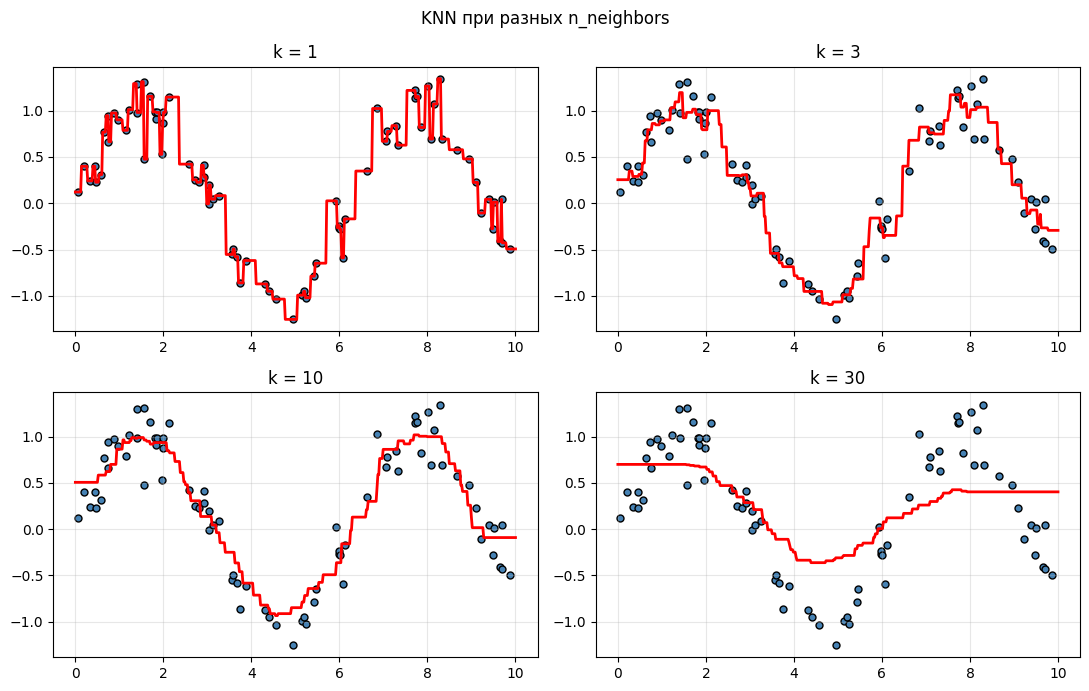

In [5]:
ks = [1, 3, 10, 30]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for ax, k in zip(axes.ravel(), ks):
    model = KNeighborsRegressor(n_neighbors=k).fit(X, y)
    ax.scatter(X, y, color='steelblue', edgecolor='k', s=25)
    ax.plot(X_grid, model.predict(X_grid), color='red', lw=2)
    ax.set_title(f'k = {k}')
    ax.grid(alpha=0.3)

plt.suptitle('KNN при разных n_neighbors')
plt.tight_layout()
plt.show()

## 5. Разница весов: `weights='uniform'` vs `weights='distance'`

- **uniform** — все соседи равны.
- **distance** — ближе сосед → больше его вес.

Второй вариант обычно даёт более «детальную» границу.

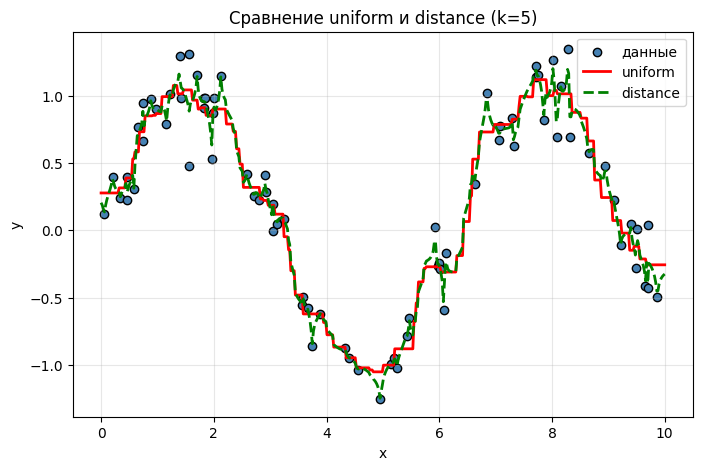

In [6]:
knn_u = KNeighborsRegressor(n_neighbors=5, weights='uniform').fit(X, y)
knn_d = KNeighborsRegressor(n_neighbors=5, weights='distance').fit(X, y)

plt.scatter(X, y, color='steelblue', edgecolor='k', label='данные')
plt.plot(X_grid, knn_u.predict(X_grid), color='red', lw=2, label='uniform')
plt.plot(X_grid, knn_d.predict(X_grid), color='green', lw=2, ls='--', label='distance')
plt.title("Сравнение uniform и distance (k=5)")
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 6. Качество модели при разных количествах соседей

Посмотрим, как меняются метрики на тестовой выборке.

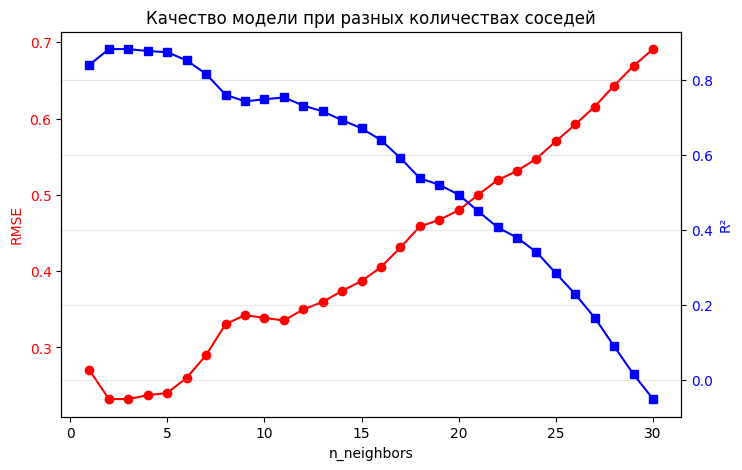

Лучшее k по RMSE: 3


In [7]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

ks = range(1, 31)
rmses, r2s = [], []

for k in ks:
    m = KNeighborsRegressor(n_neighbors=k).fit(X_tr, y_tr)
    pred = m.predict(X_te)
    rmses.append(np.sqrt(mean_squared_error(y_te, pred)))
    r2s.append(r2_score(y_te, pred))

fig, ax1 = plt.subplots()
ax1.plot(ks, rmses, 'o-', color='red', label='RMSE')
ax1.set_xlabel('n_neighbors'); ax1.set_ylabel('RMSE', color='red')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.plot(ks, r2s, 's-', color='blue', label='R²')
ax2.set_ylabel('R²', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Качество модели при разных количествах соседей')
plt.grid(alpha=0.3)
plt.show()

best_k = ks[int(np.argmin(rmses))]
print(f'Лучшее k по RMSE: {best_k}')

## 7. Метрики: MSE, RMSE, MAE, R²

  metric     value
0    MSE  0.053936
1   RMSE  0.232240
2    MAE  0.185019
3     R²  0.881198


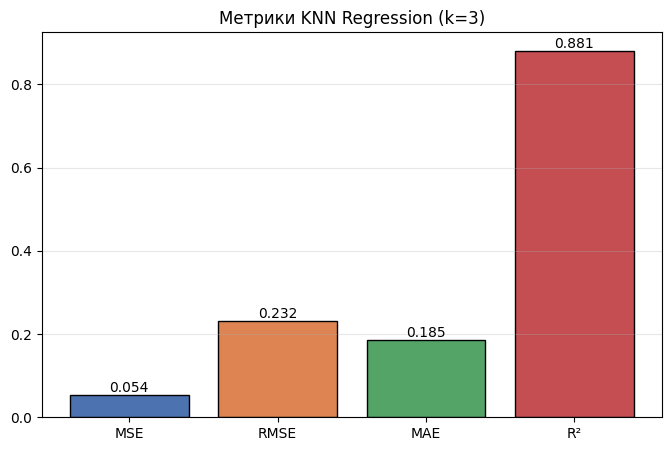

In [8]:
model = KNeighborsRegressor(n_neighbors=best_k).fit(X_tr, y_tr)
pred = model.predict(X_te)

mse  = mean_squared_error(y_te, pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_te, pred)
r2   = r2_score(y_te, pred)

metrics = pd.DataFrame({
    'metric': ['MSE', 'RMSE', 'MAE', 'R²'],
    'value':  [mse, rmse, mae, r2]
})
print(metrics)

colors = ['#4C72B0', '#DD8452', '#55A467', '#C44E52']
plt.bar(metrics['metric'], metrics['value'], color=colors, edgecolor='k')
for i, v in enumerate(metrics['value']):
    plt.text(i, v, f'{v:.3f}', ha='center', va='bottom')
plt.title(f'Метрики KNN Regression (k={best_k})')
plt.grid(alpha=0.3, axis='y')
plt.show()

#**Общий итог:**

- KNN усредняет значения **k ближайших соседей**.
- Перед обучением **обязательно надо масштабировать признаки**.
- `n_neighbors` — главный параметр: маленькое → переобучение, большое → слишком гладко.
- `weights='distance'` обычно даёт более точную, но менее ступенчатую кривую чем `weights='uniform'`.
- Для оценки качества используем **MSE / RMSE / MAE / R²**.